In [14]:
#dataset : https://www.kaggle.com/datasets/vbookshelf/rice-leaf-diseases
from google.colab import drive
drive.mount('/content/drive')
# ---------------- JUPYTER NOTEBOOK PATH ----------------
# Uncomment if using Jupyter Notebook

#dataset_path = r"C:\Users\YourName\Desktop\rice_leaf_diseases"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

In [5]:
dataset_path = '/content/drive/MyDrive/rice_leaf_diseases'

In [6]:


img_size = (224, 224)
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 3 classes.
Found 24 images belonging to 3 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.3229 - loss: 2.6049 - val_accuracy: 0.3333 - val_loss: 1.1057
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.3333 - loss: 1.1083

Validation Accuracy: 0.3333333432674408


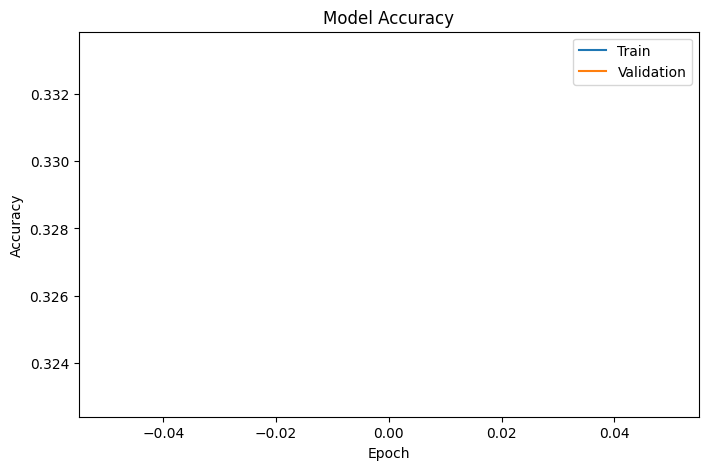


Model Saved Successfully!


In [8]:
model = models.Sequential()

# First Convolution Layer
model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(224,224,3)
))

model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2,2)))

# Third Convolution Layer
model.add(layers.Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2,2)))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(
    128,
    activation='relu'
))

# Dropout Layer
model.add(layers.Dropout(0.5))

# Output Layer (3 classes)
model.add(layers.Dense(
    3,
    activation='softmax'
))


# =========================================================
# STEP 6 — COMPILE MODEL
# =========================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# =========================================================
# STEP 7 — MODEL SUMMARY
# =========================================================

model.summary()


# =========================================================
# STEP 8 — TRAIN MODEL
# =========================================================

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=1
)


# =========================================================
# STEP 9 — EVALUATE MODEL
# =========================================================

loss, accuracy = model.evaluate(val_data)

print("\nValidation Accuracy:", accuracy)


# =========================================================
# STEP 10 — PLOT ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()


# =========================================================
# STEP 11 — SAVE MODEL
# =========================================================

# -------- GOOGLE COLAB SAVE PATH --------
# Uncomment for Colab

# model.save("/content/drive/MyDrive/rice_disease_model.h5")


# -------- JUPYTER NOTEBOOK SAVE PATH --------
# Uncomment for Jupyter Notebook

model.save("rice_disease_model.h5")

print("\nModel Saved Successfully!")


In [13]:
# Give test image path here

#test_image_path = r"C:\Users\YourName\Desktop\test.jpg"

# Example for Colab:
test_image_path = "/content/drive/MyDrive/rice_leaf_diseases/Bacterial leaf blight/DSC_0365.JPG"

img = image.load_img(
    test_image_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]

print("\nPredicted Disease:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step

Predicted Disease: Bacterial leaf blight
